In [2]:
# 0️⃣ Imports and setup
import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, ParameterGrid
import joblib

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [15]:
BASE_DIR = '/content/drive/MyDrive/Anomaly_Det/outputs/phase2'
PHASE2_OUT = os.path.join(BASE_DIR, 'phase2')
os.makedirs(os.path.join(PHASE2_OUT, 'models'), exist_ok=True)
os.makedirs(os.path.join(PHASE2_OUT, 'metrics'), exist_ok=True)
print("Directories ready")

Directories ready


In [5]:
# 1️⃣ Load dataset / features
features_path = "/content/drive/MyDrive/Anomaly_Det/outputs/phase1/data/features_v1.parquet"
features = pd.read_parquet(features_path)
features.columns = features.columns.str.strip()
id_cols = [c for c in ['CLM_ID', 'DESYNPUF_ID'] if c in features.columns]
X = features.drop(columns=id_cols) if id_cols else features.copy()

In [6]:
# Only numeric columns
X_num = X.select_dtypes(include=[np.number]).copy()
print("Numeric features shape:", X_num.shape)

Numeric features shape: (174418, 14)


In [7]:
# 2️⃣ Train / validation split
X_train_full, X_val_clean = train_test_split(X_num, test_size=0.2, random_state=RANDOM_SEED)
print('Train rows:', len(X_train_full), 'Val rows:', len(X_val_clean))

Train rows: 139534 Val rows: 34884


In [9]:
# 3️⃣ Inject anomalies for validation
def inject_anomalies(X, injection_rate=0.03, seed=RANDOM_SEED):
    X = X.copy().reset_index(drop=True)
    n = len(X)
    n_anomalies = int(n * injection_rate)
    np.random.seed(seed)
    positions = np.random.choice(n, n_anomalies, replace=False)
    y = np.zeros(n, dtype=int)

    n_monetary = int(n_anomalies * 0.30)
    n_temporal = int(n_anomalies * 0.20)
    n_coding = int(n_anomalies * 0.30)
    n_duplicate = n_anomalies - n_monetary - n_temporal - n_coding

    monetary_pos = positions[:n_monetary]
    temporal_pos = positions[n_monetary:n_monetary+n_temporal]
    coding_pos = positions[n_monetary+n_temporal:n_monetary+n_temporal+n_coding]
    duplicate_pos = positions[n_monetary+n_temporal+n_coding:]

    for pos in monetary_pos:
        if 'log_payment' in X.columns:
            X.loc[pos, 'log_payment'] *= np.random.uniform(3,5)
        if 'payment_zscore' in X.columns:
            X.loc[pos, 'payment_zscore'] *= np.random.uniform(3,5)
    for pos in temporal_pos:
        if 'claim_duration' in X.columns:
            X.loc[pos, 'claim_duration'] = int(np.random.choice([400,500,-10]))
    for pos in coding_pos:
        if 'total_code_count' in X.columns:
            X.loc[pos, 'total_code_count'] = int(np.random.choice([0,50]))
    for pos in duplicate_pos:
        noise = np.random.uniform(0.95, 1.05)
        if 'log_payment' in X.columns:
            X.loc[pos, 'log_payment'] *= noise

    y[positions] = 1
    return X, y

In [10]:
X_val_injected, y_val = inject_anomalies(X_val_clean, injection_rate=0.03, seed=RANDOM_SEED)
print("Injected anomalies:", int(y_val.sum()))

Injected anomalies: 1046


In [11]:
# 4️⃣ Scale features (OCSVM requires scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full.fillna(0))
X_val_scaled = scaler.transform(X_val_injected.fillna(0))

In [16]:
# 5️⃣ Hyperparameter grid search
param_grid = {
    'nu': [0.01, 0.03, 0.05],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']  # only relevant for rbf
}
grid = list(ParameterGrid(param_grid))
print("Grid size:", len(grid))

results = []
for i, params in enumerate(grid):
    clf = OneClassSVM(**params)
    try:
        clf.fit(X_train_scaled)
        scores = -clf.decision_function(X_val_scaled)  # higher = more anomalous
        precision, recall, _ = precision_recall_curve(y_val, scores)
        pr_auc = auc(recall, precision)
        results.append({**params, 'pr_auc': pr_auc})
    except Exception as e:
        results.append({**params, 'pr_auc': float('nan'), 'error': str(e)})
    if (i+1) % 5 == 0:
        print(f"Completed {i+1}/{len(grid)}")

results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False).reset_index(drop=True)
results_df.to_csv(os.path.join(PHASE2_OUT, 'metrics', 'ocsvm_grid_results.csv'), index=False)
print("Top results:")
print(results_df.head(10))

Grid size: 12


KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False).reset_index(drop=True)
results_df.to_csv(os.path.join(PHASE2_OUT, 'metrics', 'ocsvm_grid_results.csv'), index=False)
print("Top results:")
print(results_df.head(10))

In [13]:
# 6️⃣ Select best params and refit
best_row = results_df.dropna(subset=['pr_auc']).iloc[0]
best_params = {k: best_row[k] for k in param_grid.keys()}
print("Best params:", best_params)

clf_best = OneClassSVM(**best_params)
clf_best.fit(X_train_scaled)

# Save model & scaler
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
joblib.dump(clf_best, os.path.join(PHASE2_OUT, 'models', f'ocsvm_best_{timestamp}.pkl'))
joblib.dump(scaler, os.path.join(PHASE2_OUT, 'models', f'scaler_{timestamp}.pkl'))

summary = {
    'best_params': best_params,
    'best_pr_auc': float(best_row['pr_auc'])
}
with open(os.path.join(PHASE2_OUT, 'models', 'ocsvm_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

Best params: {'nu': np.float64(0.01), 'kernel': 'rbf', 'gamma': 'scale'}


[[  347 33491]
 [    2  1044]]
              precision    recall  f1-score   support

           0       0.99      0.01      0.02     33838
           1       0.03      1.00      0.06      1046

    accuracy                           0.04     34884
   macro avg       0.51      0.50      0.04     34884
weighted avg       0.97      0.04      0.02     34884



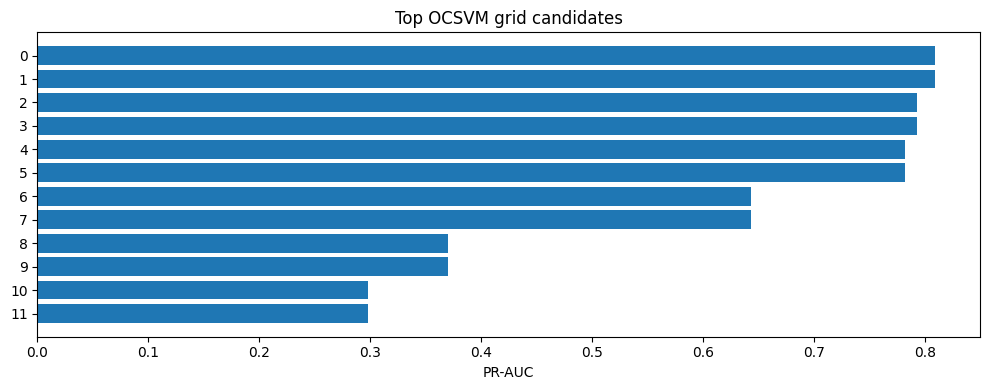

In [14]:
# 7️⃣ Evaluate on injected validation
y_pred_scores = -clf_best.decision_function(X_val_scaled)
y_pred_labels = (y_pred_scores > np.percentile(y_pred_scores, 100*best_params['nu'])).astype(int)

print(confusion_matrix(y_val, y_pred_labels))
print(classification_report(y_val, y_pred_labels))

# 8️⃣ Quick plot of top PR-AUC candidates
plt.figure(figsize=(10,4))
plot_df = results_df.head(20).copy()
plt.barh(range(len(plot_df)), plot_df['pr_auc'][::-1])
plt.yticks(range(len(plot_df)), (plot_df.index[::-1].astype(str)))
plt.xlabel('PR-AUC')
plt.title('Top OCSVM grid candidates')
plt.tight_layout()
plt.show()